In [26]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [27]:
excel_path = Path.cwd().parent / "Ejercicio_1_datos_y_etiquetas.xlsx"
df = pd.read_excel(excel_path, sheet_name="Datos")

In [28]:
diccionario_df = pd.read_excel(
   excel_path,
    sheet_name="Diccionario"
)
diccionario_df

,Variable,Descripción
0,firm_id,Identificador único de la empresa. Tratar como...
1,firm_name,Nombre ficticio de la empresa. Tratar como ide...
2,sector,Sector económico simulado.
3,reporting_period,Período común de análisis. Es constante en tod...
4,revenue_reported_mm,"Ingresos reportados, en millones."
5,revenue_growth_pct,Crecimiento de ingresos respecto del período p...
6,operating_expenses_reported_mm,"Gastos operativos reportados, en millones."
7,ebitda_reported_mm,"EBITDA reportado, en millones."
8,ebitda_margin_change_pp,Cambio del margen EBITDA respecto del período ...
9,cfo_reported_mm,"Flujo de caja operativo reportado, en millones."


In [29]:
df = pd.get_dummies(df, columns=['sector'], dtype=int)

In [31]:
df.columns

Index(['firm_id', 'firm_name', 'reporting_period', 'revenue_reported_mm',
       'revenue_growth_pct', 'operating_expenses_reported_mm',
       'ebitda_reported_mm', 'ebitda_margin_change_pp', 'cfo_reported_mm',
       'capex_total_reported_mm', 'capex_growth_pct',
       'maintenance_capex_reported_mm', 'growth_capex_reported_mm',
       'adjusted_ebitda_reported_mm', 'interest_expense_reported_mm',
       'cash_taxes_reported_mm', 'net_income_reported_mm', 'dividends_mm',
       'debt_avg_mm', 'debt_end_reported_mm', 'total_assets_reported_mm',
       'cash_reported_mm', 'accounts_receivable_reported_mm',
       'inventory_reported_mm', 'npl_reported_mm', 'npl_growth_pct',
       'provision_reported_mm', 'loan_loss_reserve_reported_mm',
       'coverage_change_pp', 'ebitda_margin_pct', 'cfo_margin_pct',
       'capex_intensity_pct', 'maintenance_capex_share_pct', 'fcf_reported_mm',
       'distributable_cash_flow_reported_mm', 'dcf_fcf_gap_mm',
       'dividend_coverage_dcf_x', 'divi

In [40]:
set(df.columns) - set(features)

{'credit_loss_coverage_reported_x',
 'dividend_coverage_dcf_x',
 'dividend_coverage_fcf_x',
 'firm_id',
 'firm_name',
 'reporting_period',
 'sector_Consumer',
 'sector_Energy',
 'sector_Financials',
 'sector_Industrials',
 'sector_Technology'}

In [42]:
df_feat

,revenue_reported_mm,revenue_growth_pct,operating_expenses_reported_mm,ebitda_reported_mm,ebitda_margin_change_pp,cfo_reported_mm,capex_total_reported_mm,capex_growth_pct,maintenance_capex_reported_mm,growth_capex_reported_mm,...,capex_intensity_pct,maintenance_capex_share_pct,fcf_reported_mm,distributable_cash_flow_reported_mm,dcf_fcf_gap_mm,debt_end_to_avg_x,leverage_avg_x,leverage_reported_x,cfo_to_ebitda_reported_x,assets_to_revenue_x
0,450.106957,0.096128,352.612135,97.494822,0.000401,71.418682,28.804520,-0.114508,17.720964,11.083555,...,0.063995,0.615215,42.614162,52.095558,9.481396,1.038741,2.321109,2.411031,0.732538,1.797173
1,191.003698,-0.008027,132.745985,58.257713,0.008613,38.250478,14.858979,0.122418,6.932402,7.926576,...,0.077794,0.466546,23.391499,38.139839,14.748339,0.955541,2.129438,2.034764,0.656574,0.936620
2,212.581800,-0.039645,153.417378,59.164422,0.012086,48.388364,48.902255,-0.013380,28.152278,20.749977,...,0.230040,0.575685,-0.513892,12.332417,12.846309,0.968734,2.620103,2.538182,0.817863,2.317827
3,206.763230,0.012685,139.493884,67.269346,0.002958,39.379762,7.138965,0.034519,3.973379,3.165586,...,0.034527,0.556576,32.240798,44.036482,11.795684,0.959788,1.128473,1.083095,0.585404,4.396203
4,96.633886,0.041338,72.479557,24.154329,0.002733,20.172502,18.916024,0.160860,12.701556,6.214468,...,0.195749,0.671471,1.256477,6.057260,4.800783,0.899404,1.567519,1.409833,0.835151,2.626447
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,166.911510,0.041387,119.902319,47.009191,-0.001184,37.204512,3.822789,-0.023768,2.391107,1.431681,...,0.022903,0.625488,33.381724,29.609079,-3.772645,0.992676,2.139831,2.124158,0.791431,4.342179
996,319.244078,0.052539,224.980915,94.263163,-0.012830,64.027712,5.810651,0.119097,3.273420,2.537231,...,0.018201,0.563348,58.217061,58.883111,0.666050,0.945796,3.244940,3.069051,0.679244,5.909210
997,183.586700,0.001782,138.868528,44.718171,0.009932,24.039876,28.939617,0.028764,20.555316,8.384302,...,0.157635,0.710283,-4.899741,12.826369,17.726110,1.039831,2.650634,2.756210,0.537586,2.303446
998,314.558586,0.032675,209.333020,105.225566,0.009169,62.501583,87.622231,0.080504,68.643250,18.978981,...,0.278556,0.783400,-25.120649,11.550454,36.671103,0.989253,1.899409,1.878997,0.593977,2.446862


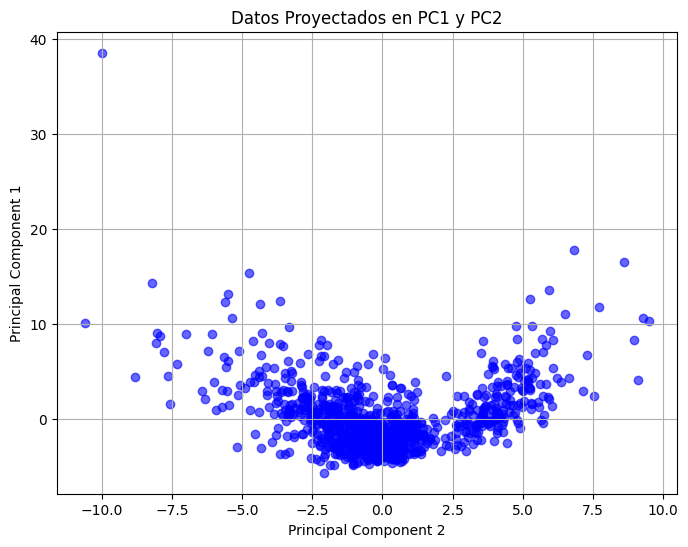

In [41]:
features = ['revenue_reported_mm', 'revenue_growth_pct',
       'operating_expenses_reported_mm', 'ebitda_reported_mm',
       'ebitda_margin_change_pp', 'cfo_reported_mm', 'capex_total_reported_mm',
       'capex_growth_pct', 'maintenance_capex_reported_mm',
       'growth_capex_reported_mm', 'adjusted_ebitda_reported_mm',
       'interest_expense_reported_mm', 'cash_taxes_reported_mm',
       'net_income_reported_mm', 'dividends_mm', 'debt_avg_mm',
       'debt_end_reported_mm', 'total_assets_reported_mm', 'cash_reported_mm',
       'accounts_receivable_reported_mm', 'inventory_reported_mm',
       'npl_reported_mm', 'npl_growth_pct', 'provision_reported_mm',
       'loan_loss_reserve_reported_mm', 'coverage_change_pp',
       'ebitda_margin_pct', 'cfo_margin_pct', 'capex_intensity_pct',
       'maintenance_capex_share_pct', 'fcf_reported_mm',
       'distributable_cash_flow_reported_mm', 'dcf_fcf_gap_mm',
       'debt_end_to_avg_x', 'leverage_avg_x', 'leverage_reported_x',
 'cfo_to_ebitda_reported_x',
       'assets_to_revenue_x']

df_feat = df[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_feat)

# PCA con TODOS los componentes
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Plot primeros 2 componentes
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 1], X_pca[:, 0], alpha=0.6, c="blue")
plt.xlabel("Principal Component 2")
plt.ylabel("Principal Component 1")
plt.title("Datos Proyectados en PC1 y PC2")
plt.grid(True)
plt.show()

/var/folders/cp/4t8kc0w92n711zvv5kl2gdbm0000gn/T/ipykernel_94453/450348102.py:9: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  distances = np.abs(np.cross(line_vec, np.vstack([x, cumvar]).T - start)) / np.linalg.norm(line_vec)


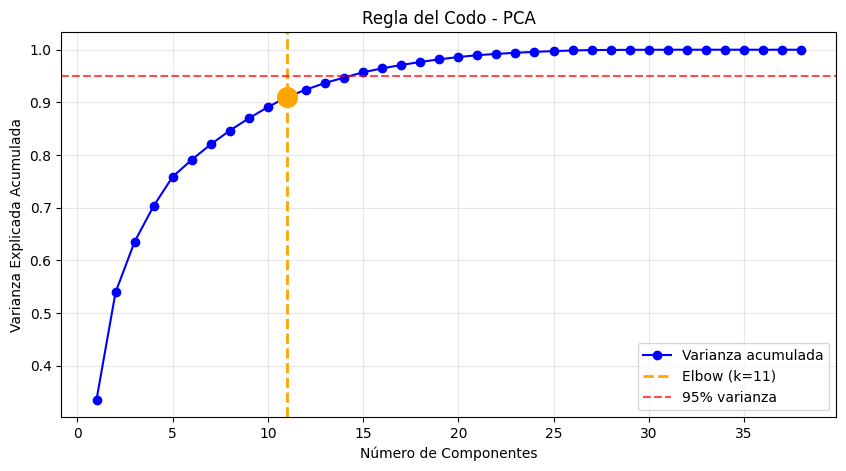

Componentes por método del codo: 11
Componentes para 95% varianza: 15
Varianza explicada con k=11: 0.9100


In [35]:
# Detectar el codo automáticamente (método de máxima distancia)
def find_elbow_by_max_distance(cumvar):
    n = len(cumvar)
    x = np.arange(1, n + 1).astype(float)
    start = np.array([x[0], cumvar[0]])
    end = np.array([x[-1], cumvar[-1]])
    line_vec = end - start
    # distancia perpendicular punto-línea
    distances = np.abs(np.cross(line_vec, np.vstack([x, cumvar]).T - start)) / np.linalg.norm(line_vec)
    elbow_idx = distances.argmax()
    return elbow_idx + 1, distances  # k (1-based)

cumsum_var = np.cumsum(pca.explained_variance_ratio_)
k_elbow, _ = find_elbow_by_max_distance(cumsum_var)
k_95 = np.argmax(cumsum_var >= 0.95) + 1

# Plot
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumsum_var) + 1), cumsum_var, 'bo-', label='Varianza acumulada')
plt.axvline(k_elbow, color='orange', linestyle='--', linewidth=2, label=f'Elbow (k={k_elbow})')
plt.scatter([k_elbow], [cumsum_var[k_elbow - 1]], s=200, color='orange', zorder=5)
plt.axhline(y=0.95, color='r', linestyle='--', alpha=0.7, label='95% varianza')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Explicada Acumulada')
plt.title('Regla del Codo - PCA')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print(f"Componentes por método del codo: {k_elbow}")
print(f"Componentes para 95% varianza: {k_95}")
print(f"Varianza explicada con k={k_elbow}: {cumsum_var[k_elbow - 1]:.4f}")


In [36]:
# Matriz de loadings: cada fila es un PC, cada columna es una feature
loadings = pca.components_

# Crear un DataFrame para verlo mejor
loadings_df = pd.DataFrame(
    loadings.T,  # transponer para que features sean filas
    columns=[f'PC{i+1}' for i in range(loadings.shape[0])],
    index=features
)

loadings_df

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC29,PC30,PC31,PC32,PC33,PC34,PC35,PC36,PC37,PC38
revenue_reported_mm,0.225878,-0.152694,-0.072282,-0.082710,-0.211880,0.052074,-0.020795,-0.025789,-0.006056,0.090244,...,-0.063501,-0.007456,-0.015928,0.095689,0.127928,0.000000e+00,0.000000e+00,-0.000000e+00,-0.000000e+00,7.647679e-01
revenue_growth_pct,0.010457,0.023357,0.344321,0.067121,-0.060505,0.181223,-0.154095,0.177246,-0.008441,-0.254418,...,0.010497,0.004036,0.000318,0.000057,0.001963,1.861278e-15,6.227849e-16,-2.094822e-15,-1.330495e-15,4.465952e-15
operating_expenses_reported_mm,0.184302,-0.187588,-0.114511,-0.101981,-0.263344,0.081580,-0.043835,-0.025881,-0.011366,0.134999,...,-0.090096,-0.003712,0.007868,-0.070917,-0.101707,-1.861536e-14,-3.280363e-14,2.495214e-14,5.150217e-14,-6.044743e-01
ebitda_reported_mm,0.275027,-0.015169,0.062505,-0.007216,-0.012796,-0.042545,0.047500,-0.018285,0.010042,-0.056442,...,0.026441,-0.015508,-0.075942,0.520329,0.714330,3.540339e-13,-2.225544e-12,8.324957e-13,1.675382e-12,-2.230267e-01
ebitda_margin_change_pp,0.036276,0.010899,0.320761,0.042195,-0.022797,0.351893,-0.077868,0.149861,-0.031319,-0.200986,...,0.003476,-0.001300,-0.000975,-0.000601,-0.001554,4.246081e-16,1.446753e-15,3.248567e-17,-2.475222e-15,-1.881030e-15
cfo_reported_mm,0.267469,0.013509,0.108897,0.022129,0.007522,-0.034416,0.074914,-0.044077,-0.022839,0.074020,...,-0.050997,-0.274932,0.018829,-0.081408,-0.101760,2.326779e-01,6.816422e-01,1.042372e-01,-2.411891e-01,-5.425449e-13
capex_total_reported_mm,0.158233,-0.262999,-0.044902,-0.002295,0.234794,-0.002524,-0.009390,0.005810,-0.012570,0.030105,...,-0.031447,-0.079938,0.010919,-0.047385,-0.060154,-2.434397e-01,-1.807015e-02,4.496869e-01,6.720661e-01,2.729825e-13
capex_growth_pct,0.007353,0.008520,0.157360,-0.000324,0.053668,0.383821,-0.293937,0.289978,0.650579,0.260454,...,-0.001353,-0.001966,-0.001042,0.000633,-0.000042,4.412278e-16,-1.453955e-15,-5.662478e-15,9.640878e-16,5.272272e-16
maintenance_capex_reported_mm,0.156302,-0.246865,-0.031487,0.010796,0.247195,0.088963,0.132779,-0.013454,-0.021795,0.021329,...,0.113451,-0.187330,0.018142,-0.085433,-0.104476,-3.509411e-01,-2.480723e-01,-3.050992e-01,-3.959394e-01,-2.685217e-13
growth_capex_reported_mm,0.139438,-0.255198,-0.062903,-0.025712,0.179219,-0.168074,-0.265881,0.039924,0.005929,0.041776,...,-0.289777,0.126076,-0.003720,0.028289,0.028698,3.243823e-03,-2.505887e-01,-2.076177e-01,-1.604136e-01,7.764998e-14


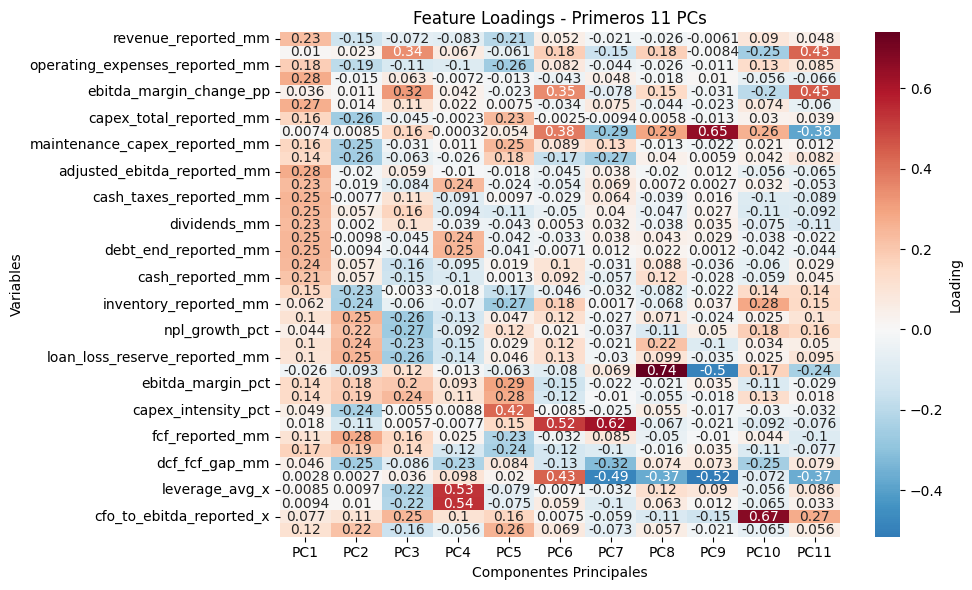

In [37]:
import seaborn as sns

# Heatmap de los primeros k componentes
plt.figure(figsize=(10, 6))
sns.heatmap(loadings_df.iloc[:, :k_elbow], annot=True, cmap='RdBu_r', center=0, 
            cbar_kws={'label': 'Loading'})
plt.title(f'Feature Loadings - Primeros {k_elbow} PCs')
plt.ylabel('Variables')
plt.xlabel('Componentes Principales')
plt.tight_layout()
plt.show()

In [38]:
for i in range(k_elbow):
    top_features = loadings_df[f'PC{i+1}'].abs().nlargest(5)
    print(f"\nPC{i+1} - Top 5 variables:")
    print(top_features)


PC1 - Top 5 variables:
adjusted_ebitda_reported_mm    0.275108
ebitda_reported_mm             0.275027
cfo_reported_mm                0.267469
cash_taxes_reported_mm         0.251438
debt_avg_mm                    0.248518
Name: PC1, dtype: float64

PC2 - Top 5 variables:
fcf_reported_mm             0.280885
capex_total_reported_mm     0.262999
growth_capex_reported_mm    0.255198
dcf_fcf_gap_mm              0.254732
npl_reported_mm             0.251521
Name: PC2, dtype: float64

PC3 - Top 5 variables:
revenue_growth_pct               0.344321
ebitda_margin_change_pp          0.320761
npl_growth_pct                   0.267164
npl_reported_mm                  0.256335
loan_loss_reserve_reported_mm    0.255582
Name: PC3, dtype: float64

PC4 - Top 5 variables:
leverage_reported_x             0.537584
leverage_avg_x                  0.529733
debt_end_reported_mm            0.251854
debt_avg_mm                     0.244736
interest_expense_reported_mm    0.242972
Name: PC4, dtype: float64


COMPONENTE PRINCIPAL 1 (PC1)
adjusted_ebitda_reported_mm            0.275108
ebitda_reported_mm                     0.275027
cfo_reported_mm                        0.267469
cash_taxes_reported_mm                 0.251438
debt_avg_mm                            0.248518
debt_end_reported_mm                   0.247472
net_income_reported_mm                 0.245803
total_assets_reported_mm               0.243871
dividends_mm                           0.231106
interest_expense_reported_mm           0.230767
revenue_reported_mm                    0.225878
cash_reported_mm                       0.210186
operating_expenses_reported_mm         0.184302
distributable_cash_flow_reported_mm    0.170166
capex_total_reported_mm                0.158233
maintenance_capex_reported_mm          0.156302
accounts_receivable_reported_mm        0.151272
ebitda_margin_pct                      0.141929
growth_capex_reported_mm               0.139438
cfo_margin_pct                         0.136433
assets_to_r

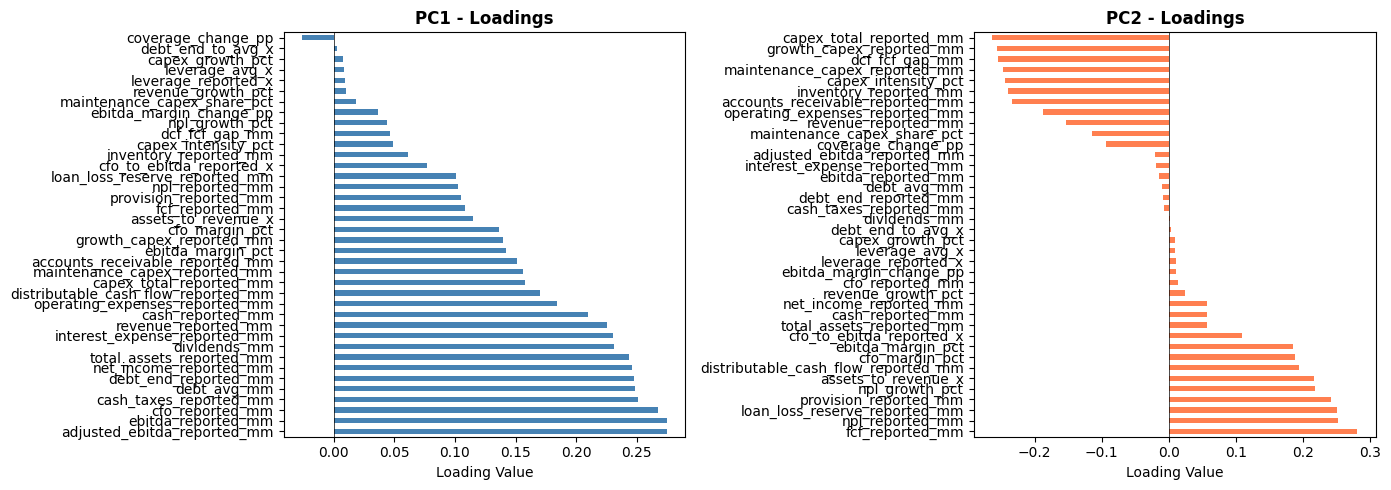


INTERPRETACIÓN

PC1 (explica 33.51% varianza):
  Positivas (contribuyen igual dirección): ['adjusted_ebitda_reported_mm', 'ebitda_reported_mm', 'cfo_reported_mm']
  Negativas (contribuyen opuesta): []

PC2 (explica 20.39% varianza):
  Positivas: ['fcf_reported_mm', 'npl_reported_mm', 'loan_loss_reserve_reported_mm']
  Negativas: ['maintenance_capex_share_pct', 'revenue_reported_mm', 'operating_expenses_reported_mm']


In [39]:
# Extraer los loadings de los primeros 2 componentes
loadings_df = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=features
)

# Ver los loadings de PC1 y PC2
print("=" * 60)
print("COMPONENTE PRINCIPAL 1 (PC1)")
print("=" * 60)
pc1_sorted = loadings_df['PC1'].sort_values(ascending=False)
print(pc1_sorted)

print("\n" + "=" * 60)
print("COMPONENTE PRINCIPAL 2 (PC2)")
print("=" * 60)
pc2_sorted = loadings_df['PC2'].sort_values(ascending=False)
print(pc2_sorted)

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PC1
pc1_sorted.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('PC1 - Loadings', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Loading Value')
axes[0].axvline(x=0, color='black', linestyle='-', linewidth=0.5)

# PC2
pc2_sorted.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('PC2 - Loadings', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Loading Value')
axes[1].axvline(x=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()

# Interpretación resumida
print("\n" + "=" * 60)
print("INTERPRETACIÓN")
print("=" * 60)
print(f"\nPC1 (explica {pca.explained_variance_ratio_[0]:.2%} varianza):")
print(f"  Positivas (contribuyen igual dirección): {pc1_sorted[pc1_sorted > 0.1].index.tolist()[:3]}")
print(f"  Negativas (contribuyen opuesta): {pc1_sorted[pc1_sorted < -0.1].index.tolist()[:3]}")

print(f"\nPC2 (explica {pca.explained_variance_ratio_[1]:.2%} varianza):")
print(f"  Positivas: {pc2_sorted[pc2_sorted > 0.1].index.tolist()[:3]}")
print(f"  Negativas: {pc2_sorted[pc2_sorted < -0.1].index.tolist()[:3]}")